After a ``PCA-based`` fit, ``dPULearn().project()`` maps held-out samples from the **same feature space** into the fitted principal-component coordinates (the ``PCi`` columns of ``df_pu_``). This lets you place new proteins alongside the identified negatives, for example to overlay an additional group in the PCA plot. We load an example dataset, hold out a few proteins, and fit dPULearn on the rest:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import aaanalysis as aa
aa.options["verbose"] = False
# γ-secretase substrates (positives) + proteins with unknown status (unlabeled)
df_seq = aa.load_dataset(name="DOM_GSEC_PU")
labels_all = df_seq["label"].to_numpy()
df_feat = aa.load_features(name="DOM_GSEC")
sf = aa.SequenceFeature()
X = sf.feature_matrix(features=df_feat["feature"], df_parts=sf.get_df_parts(df_seq=df_seq))
# Hold out 10 proteins to project after fitting; fit dPULearn on the rest
rng = np.random.default_rng(0)
mask_new = np.zeros(len(X), dtype=bool)
mask_new[rng.choice(len(X), size=10, replace=False)] = True
X_fit, labels_fit, X_new = X[~mask_new], labels_all[~mask_new], X[mask_new]
n_pos = int((labels_fit == 1).sum())
dpul = aa.dPULearn().fit(X_fit, labels=labels_fit, n_neg=n_pos)

Pass the held-out feature matrix to ``project()`` to obtain their coordinates in the fitted PC space. The returned DataFrame carries the same ``PCi`` columns as ``dPULearn().df_pu_``:

In [2]:
df_proj = dpul.project(X_new)
aa.display_df(df_proj, n_rows=10, show_shape=True)

DataFrame shape: (10, 7)


,PC1 (56.0%),PC2 (7.4%),PC3 (2.9%),PC4 (2.8%),PC5 (2.1%),PC6 (1.7%),PC7 (1.6%)
1,0.043861,-0.017151,0.009517,0.080963,0.068627,0.014991,0.022464
2,0.047893,0.016042,-0.024519,-0.004018,0.017070,-0.020411,-0.038839
3,0.047519,0.031883,-0.022193,0.033516,0.022347,-0.033253,-0.026722
4,0.039927,-0.045211,-0.047730,0.029938,0.022512,-0.019787,-0.021570
5,0.045709,0.012006,0.010413,0.034537,-0.045231,0.014827,-0.024091
6,0.043690,-0.028165,-0.065779,0.050376,0.035807,0.006461,-0.011233
7,0.042007,-0.026123,-0.050801,0.013587,-0.016452,-0.023217,-0.040908
8,0.031670,-0.021102,0.012709,0.018437,0.023056,0.075416,0.057489
9,0.042825,-0.034355,0.031250,0.041629,0.000038,0.059496,-0.010246
10,0.046230,-0.029815,-0.003327,0.039344,-0.014050,-0.001047,-0.004704


The ``method`` parameter selects how the feature-space to PC-space map is reconstructed. All methods reproduce ``df_pu_`` on the fitted samples (exact on the fit pool) and interpolate for new samples: ``'lstsq'`` (default) is the affine least-squares map, ``'components'`` the exact PCA-geometry map, and ``'ridge'`` an L2-regularized map:

In [3]:
for method in ["lstsq", "components", "ridge"]:
    df_m = dpul.project(X_new, method=method)
    print(method, "->", df_m.shape, "| PC1 range:",
          round(df_m.iloc[:, 0].min(), 3), "to", round(df_m.iloc[:, 0].max(), 3))

lstsq -> (10, 7) | PC1 range: 0.032 to 0.048
components -> (10, 7) | PC1 range: 0.032 to 0.048
ridge -> (10, 7) | PC1 range: 0.032 to 0.048


For ``method='ridge'``, the ``alpha`` parameter sets the L2 regularization strength (default 1.0). Larger values shrink projected coordinates toward the fit-pool center, stabilizing extrapolation when there are many more features than samples; as ``alpha`` approaches 0 the map converges to ``'lstsq'``:

In [4]:
for alpha in [0.01, 1.0, 100.0]:
    df_a = dpul.project(X_new, method="ridge", alpha=alpha)
    print("alpha =", alpha, "-> mean |PC1| =", round(df_a.iloc[:, 0].abs().mean(), 3))

alpha = 0.01 -> mean |PC1| = 0.043
alpha = 1.0 -> mean |PC1| = 0.043
alpha = 100.0 -> mean |PC1| = 0.041


The projected coordinates can be overlaid on the PCA plot as an additional group via ``dPULearnPlot().pca(df_pu_add=...)`` (see the ``dPULearnPlot.pca`` example for details):

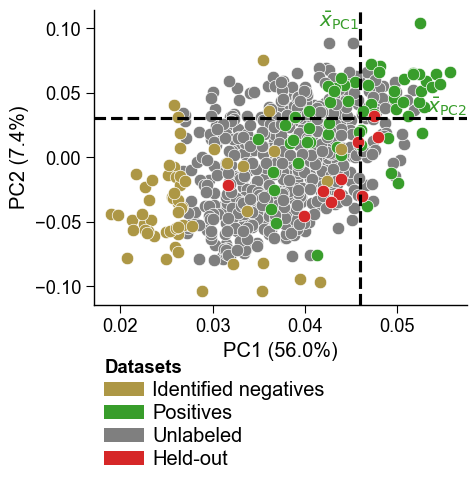

In [5]:
aa.plot_settings(font_scale=0.8)
aa.dPULearnPlot().pca(df_pu=dpul.df_pu_, labels=dpul.labels_,
                      df_pu_add=df_proj, names_add="Held-out", colors_add="tab:red")
plt.tight_layout()
plt.show()